# 🛍️ Shopping Trends — Exploratory Data Analysis

> **Author:** Md Rayan  
> **Goal:** Uncover purchasing patterns from customer shopping data to drive actionable sales strategy.

---

### 📋 Table of Contents
1. Imports & Setup
2. Data Loading
3. Data Profiling
4. Data Cleaning
5. Univariate Analysis
6. Bivariate Analysis
7. Revenue by Category
8. Payment & Shipping Mix
9. Correlation Heatmap
10. Discount & Subscription Impact
11. Revenue by Location
12. Key Insights & Recommendations

## 1. Imports & Setup

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

os.makedirs('../outputs/figures', exist_ok=True)

print('Libraries loaded')
print(f'  pandas  : {pd.__version__}')
print(f'  numpy   : {np.__version__}')
print(f'  seaborn : {sns.__version__}')

Libraries loaded
  pandas  : 2.2.3
  numpy   : 2.1.3
  seaborn : 0.13.2


## 2. Data Loading

In [9]:
DATA_PATH = '../data/shopping_trends.csv'

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at '{DATA_PATH}'.\n"
        "Download from Kaggle and place the CSV in the data/ folder:\n"
        "https://www.kaggle.com/datasets/iamsouravbanerjee/customer-shopping-trends-dataset"
    )

df = pd.read_csv(DATA_PATH)
print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')
df.head()

Rows    : 1,000
Columns : 18


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Frequency of Purchases
0,1,56,Male,Blouse,Outerwear,141.91,Florida,XL,Green,Fall,5.0,No,Credit Card,Express,Yes,No,49,Quarterly
1,2,69,Male,Sweater,Footwear,34.94,Florida,L,Black,Winter,3.1,No,PayPal,Store Pickup,No,Yes,0,Quarterly
2,3,46,Male,Hat,Outerwear,374.86,Georgia,XL,Red,Spring,4.2,No,PayPal,Standard,No,Yes,37,Bi-Weekly
3,4,32,Female,Socks,Accessories,71.04,California,L,White,Fall,4.3,Yes,Credit Card,Express,No,Yes,2,Monthly
4,5,60,Male,Belt,Clothing,171.16,Georgia,XL,NaN,Fall,4.0,No,Debit Card,Express,Yes,Yes,36,Weekly


## 3. Data Profiling

In [10]:
print('=== Column Data Types ===')
print(df.dtypes)

=== Column Data Types ===
Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)     float64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Payment Method             object
Shipping Type              object
Discount Applied           object
Promo Code Used            object
Previous Purchases          int64
Frequency of Purchases     object
dtype: object


In [11]:
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

=== Missing Values ===
               Missing Count  Missing %
Size                      30        3.0
Color                     30        3.0
Review Rating             30        3.0


In [12]:
print('=== Statistical Summary ===')
df.describe()

=== Statistical Summary ===


,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,1000.000000,1000.00000,1000.000000,970.000000,1000.00000
mean,500.500000,43.81900,263.360890,3.737835,24.19800
std,288.819436,14.99103,139.106091,0.726288,14.36876
min,1.000000,18.00000,20.090000,2.500000,0.00000
25%,250.750000,31.00000,141.775000,3.100000,12.00000
50%,500.500000,44.00000,271.470000,3.700000,23.00000
75%,750.250000,56.00000,385.237500,4.400000,37.00000
max,1000.000000,69.00000,499.860000,5.000000,49.00000


## 4. Data Cleaning

In [13]:
# Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f'Duplicates removed : {before - len(df)}')

# Impute numeric columns with median (Pandas 3.x safe)
num_cols = df.select_dtypes(include='number').columns.tolist()
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Impute categorical columns with mode (Pandas 3.x safe)
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f'Missing values remaining : {df.isnull().sum().sum()}')
print(f'Final shape              : {df.shape}')
print('Data cleaning complete')

Duplicates removed : 0
Missing values remaining : 0
Final shape              : (1000, 18)
Data cleaning complete


## 5. Univariate Analysis

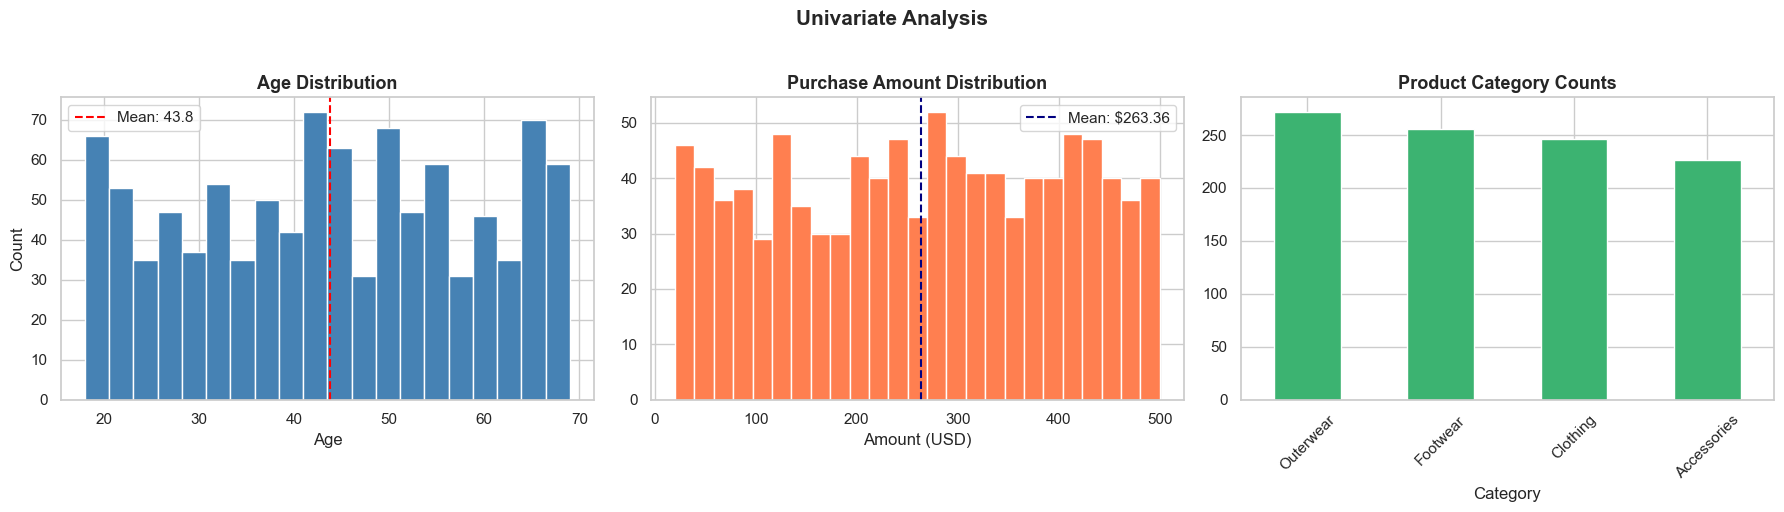

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Univariate Analysis', fontsize=15, fontweight='bold', y=1.02)

# Age distribution
axes[0].hist(df['Age'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].axvline(df['Age'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["Age"].mean():.1f}')
axes[0].legend()

# Purchase amount distribution
axes[1].hist(df['Purchase Amount (USD)'], bins=25, color='coral', edgecolor='white')
axes[1].set_title('Purchase Amount Distribution')
axes[1].set_xlabel('Amount (USD)')
axes[1].axvline(df['Purchase Amount (USD)'].mean(), color='navy', linestyle='--',
                label=f'Mean: ${df["Purchase Amount (USD)"].mean():.2f}')
axes[1].legend()

# Category counts
df['Category'].value_counts().plot(kind='bar', ax=axes[2],
                                    color='mediumseagreen', edgecolor='white')
axes[2].set_title('Product Category Counts')
axes[2].set_xlabel('Category')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/figures/univariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Bivariate Analysis

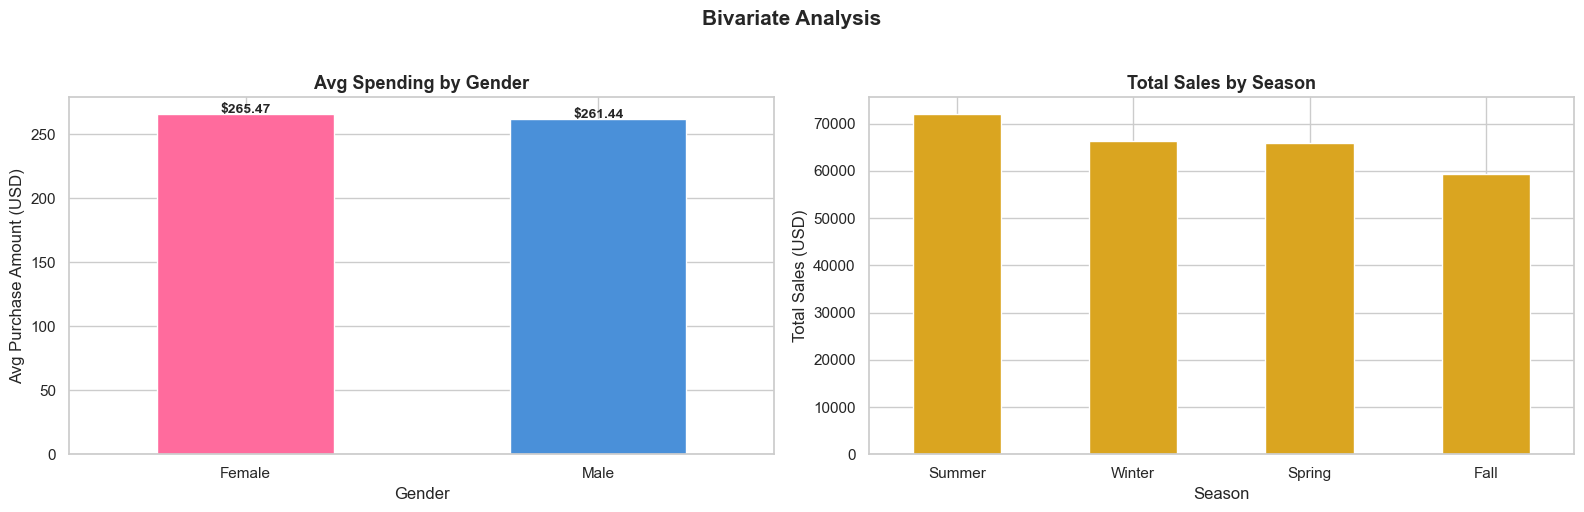

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Bivariate Analysis', fontsize=15, fontweight='bold', y=1.02)

# Gender vs Avg Spending
gender_spend = df.groupby('Gender')['Purchase Amount (USD)'].mean().sort_values(ascending=False)
gender_spend.plot(kind='bar', ax=axes[0], color=['#FF6B9D', '#4A90D9'], edgecolor='white')
axes[0].set_title('Avg Spending by Gender')
axes[0].set_ylabel('Avg Purchase Amount (USD)')
axes[0].set_xlabel('Gender')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(gender_spend):
    axes[0].text(i, v + 1, f'${v:.2f}', ha='center', fontsize=10, fontweight='bold')

# Season vs Total Sales
season_sales = df.groupby('Season')['Purchase Amount (USD)'].sum().sort_values(ascending=False)
season_sales.plot(kind='bar', ax=axes[1], color='goldenrod', edgecolor='white')
axes[1].set_title('Total Sales by Season')
axes[1].set_ylabel('Total Sales (USD)')
axes[1].set_xlabel('Season')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../outputs/figures/bivariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

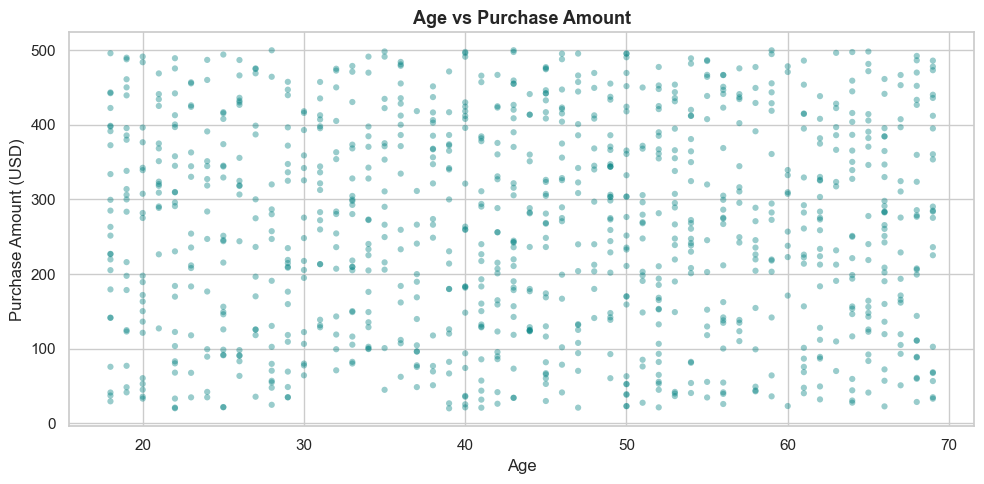

In [16]:
# Age vs Purchase Amount scatter
plt.figure(figsize=(10, 5))
plt.scatter(df['Age'], df['Purchase Amount (USD)'],
            alpha=0.4, color='teal', edgecolors='none', s=20)
plt.title('Age vs Purchase Amount')
plt.xlabel('Age')
plt.ylabel('Purchase Amount (USD)')
plt.tight_layout()
plt.savefig('../outputs/figures/age_vs_purchase.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Revenue by Category

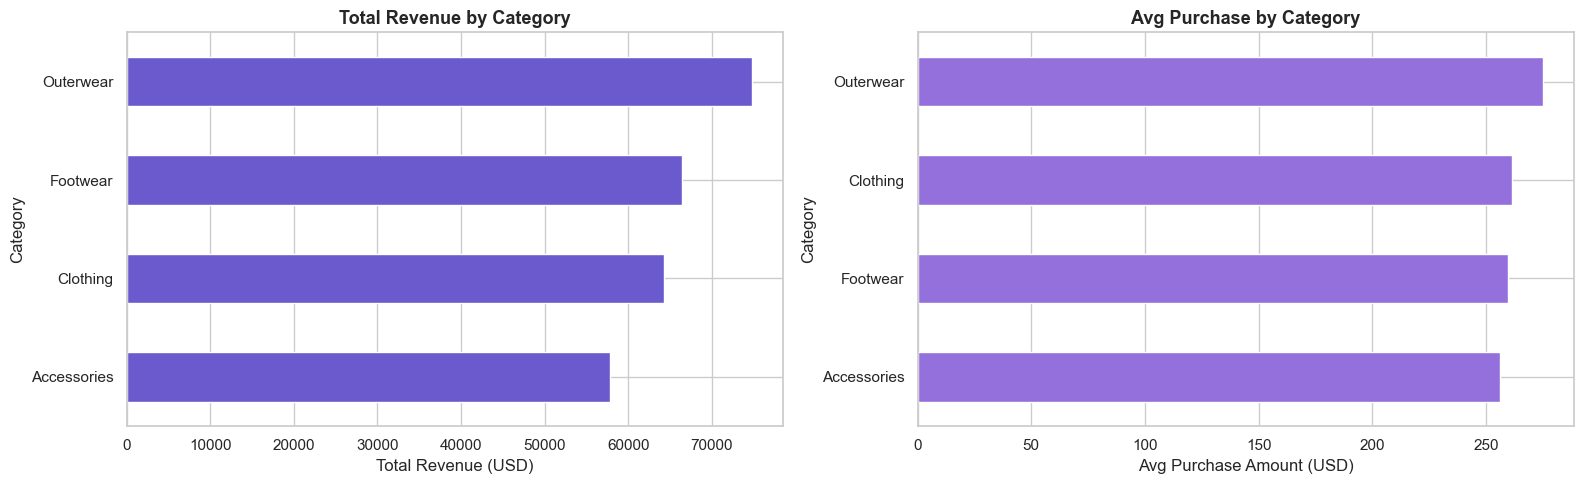

Top category by revenue : Outerwear  ($74,786.26)


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Total revenue
cat_rev = df.groupby('Category')['Purchase Amount (USD)'].sum().sort_values(ascending=True)
cat_rev.plot(kind='barh', ax=axes[0], color='slateblue', edgecolor='white')
axes[0].set_title('Total Revenue by Category')
axes[0].set_xlabel('Total Revenue (USD)')

# Avg purchase
cat_avg = df.groupby('Category')['Purchase Amount (USD)'].mean().sort_values(ascending=True)
cat_avg.plot(kind='barh', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].set_title('Avg Purchase by Category')
axes[1].set_xlabel('Avg Purchase Amount (USD)')

plt.tight_layout()
plt.savefig('../outputs/figures/category_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Top category by revenue : {cat_rev.idxmax()}  (${cat_rev.max():,.2f})')

## 8. Payment & Shipping Mix

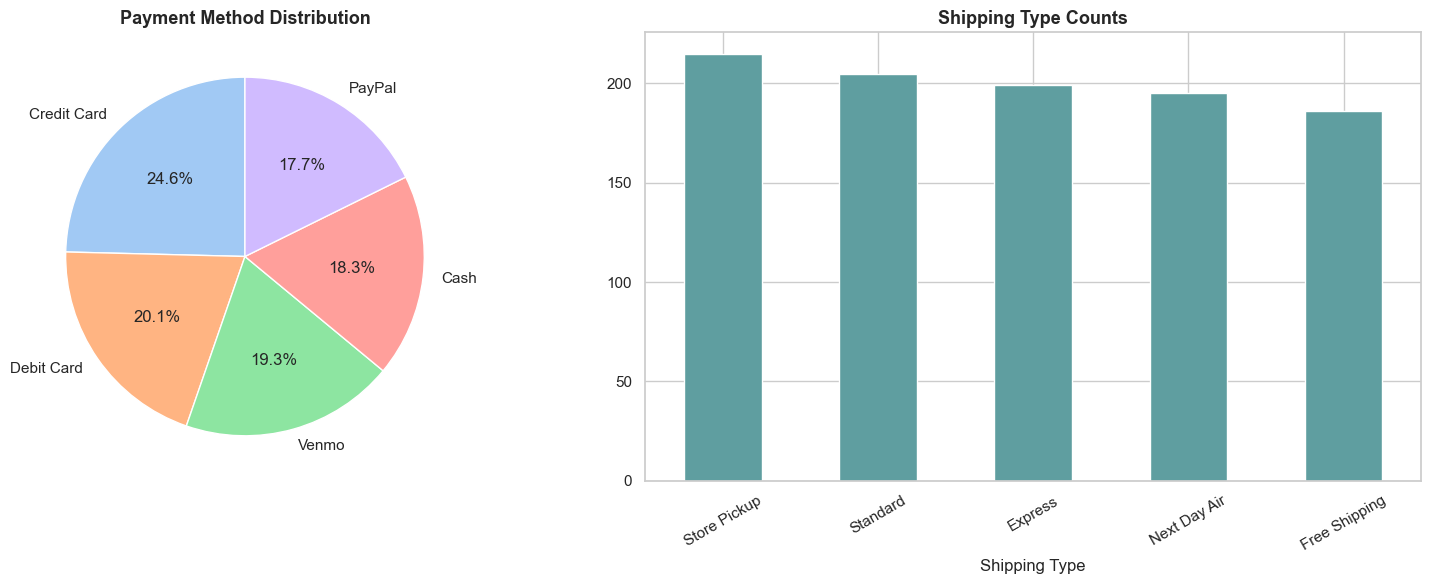

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Payment method pie
pay_counts = df['Payment Method'].value_counts()
axes[0].pie(pay_counts, labels=pay_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('pastel', len(pay_counts)), startangle=90)
axes[0].set_title('Payment Method Distribution')

# Shipping type bar
df['Shipping Type'].value_counts().plot(
    kind='bar', ax=axes[1], color='cadetblue', edgecolor='white')
axes[1].set_title('Shipping Type Counts')
axes[1].set_xlabel('Shipping Type')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../outputs/figures/payment_shipping.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Correlation Heatmap

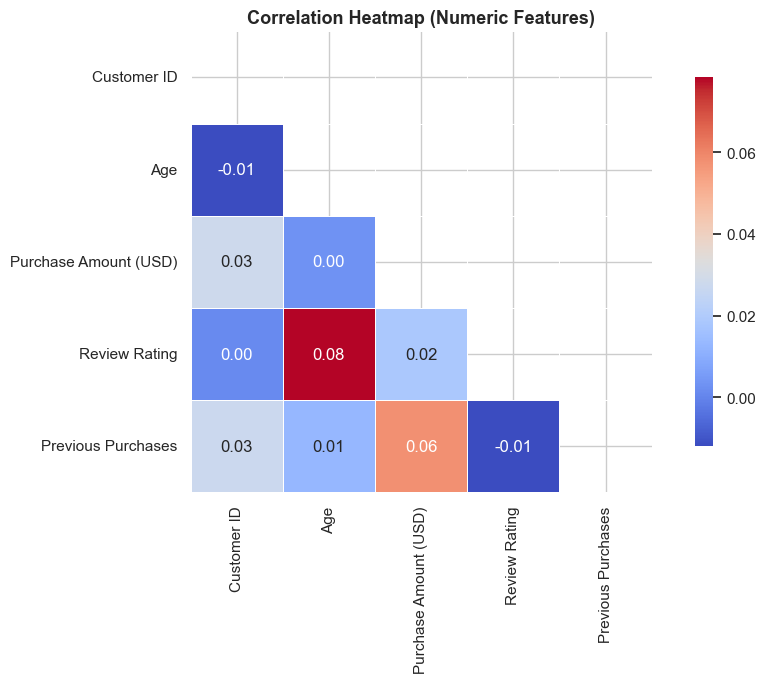

In [19]:
fig, ax = plt.subplots(figsize=(10, 7))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Discount & Subscription Impact

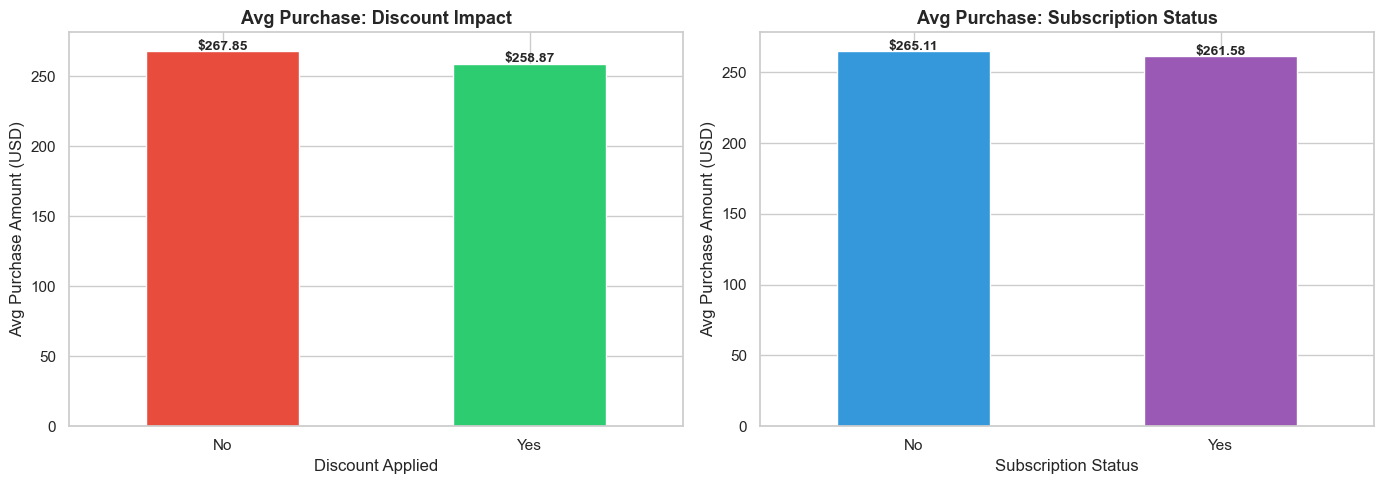

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Discount impact
disc_avg = df.groupby('Discount Applied')['Purchase Amount (USD)'].mean()
disc_avg.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[0].set_title('Avg Purchase: Discount Impact')
axes[0].set_ylabel('Avg Purchase Amount (USD)')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(disc_avg):
    axes[0].text(i, v + 1, f'${v:.2f}', ha='center', fontsize=10, fontweight='bold')

# Subscription impact
sub_avg = df.groupby('Subscription Status')['Purchase Amount (USD)'].mean()
sub_avg.plot(kind='bar', ax=axes[1], color=['#3498db', '#9b59b6'], edgecolor='white')
axes[1].set_title('Avg Purchase: Subscription Status')
axes[1].set_ylabel('Avg Purchase Amount (USD)')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(sub_avg):
    axes[1].text(i, v + 1, f'${v:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/discount_subscription.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Revenue by Location

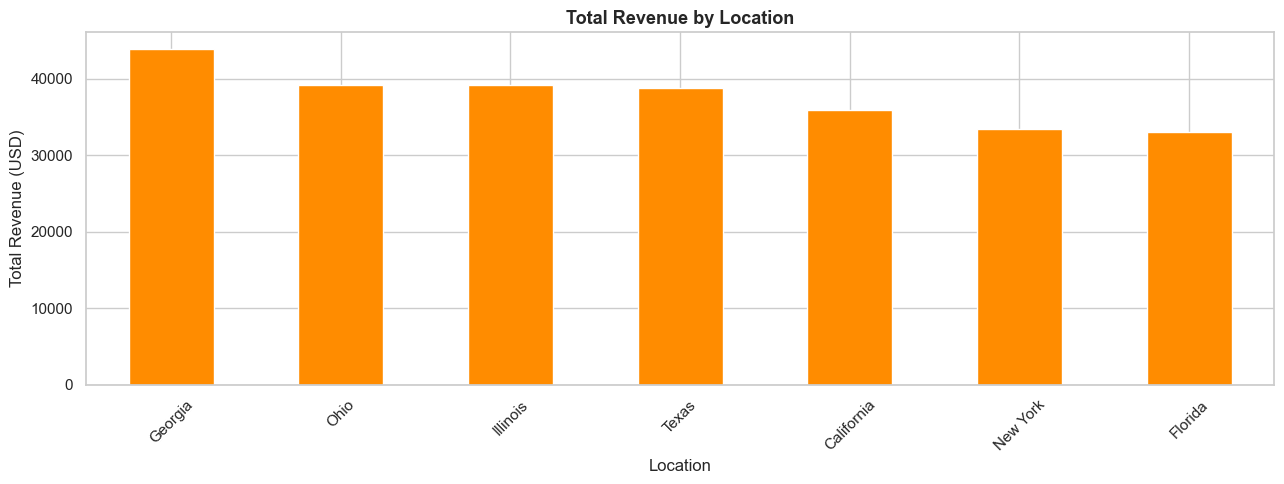

Top location: Georgia  ($43,872.55)


In [21]:
fig, ax = plt.subplots(figsize=(13, 5))
loc_rev = df.groupby('Location')['Purchase Amount (USD)'].sum().sort_values(ascending=False)
loc_rev.plot(kind='bar', ax=ax, color='darkorange', edgecolor='white')
ax.set_title('Total Revenue by Location')
ax.set_ylabel('Total Revenue (USD)')
ax.set_xlabel('Location')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../outputs/figures/revenue_by_location.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Top location: {loc_rev.idxmax()}  (${loc_rev.max():,.2f})')

## 12. Key Insights & Recommendations

In [22]:
top_category = df.groupby('Category')['Purchase Amount (USD)'].sum().idxmax()
top_season   = df.groupby('Season')['Purchase Amount (USD)'].sum().idxmax()
top_location = df.groupby('Location')['Purchase Amount (USD)'].sum().idxmax()
top_gender   = df.groupby('Gender')['Purchase Amount (USD)'].mean().idxmax()
top_payment  = df['Payment Method'].value_counts().idxmax()
avg_purchase = df['Purchase Amount (USD)'].mean()
avg_age      = df['Age'].mean()

print('=' * 55)
print('       KEY INSIGHTS SUMMARY')
print('=' * 55)
print(f'  Avg Purchase Amount  : ${avg_purchase:.2f}')
print(f'  Avg Customer Age     : {avg_age:.1f} years')
print(f'  Top Category         : {top_category}')
print(f'  Peak Season          : {top_season}')
print(f'  Top Location         : {top_location}')
print(f'  Higher Avg Spender   : {top_gender}')
print(f'  Most Used Payment    : {top_payment}')
print('=' * 55)
print()
print('BUSINESS RECOMMENDATIONS')
print(f'  1. Boost inventory for "{top_category}" before {top_season} season')
print(f'  2. Run targeted campaigns in {top_location} — highest revenue region')
print(f'  3. Tailor premium offers toward {top_gender} shoppers')
print(f'  4. Optimize {top_payment} checkout — most popular payment method')
print( '  5. Launch loyalty program for customers with 10+ previous purchases')

       KEY INSIGHTS SUMMARY
  Avg Purchase Amount  : $263.36
  Avg Customer Age     : 43.8 years
  Top Category         : Outerwear
  Peak Season          : Summer
  Top Location         : Georgia
  Higher Avg Spender   : Female
  Most Used Payment    : Credit Card

BUSINESS RECOMMENDATIONS
  1. Boost inventory for "Outerwear" before Summer season
  2. Run targeted campaigns in Georgia — highest revenue region
  3. Tailor premium offers toward Female shoppers
  4. Optimize Credit Card checkout — most popular payment method
  5. Launch loyalty program for customers with 10+ previous purchases
